# IMPORT REQUIRED LIBRARIES

In [60]:
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


# LOAD DATA

In [61]:
df = pd.read_csv("/content/creditcard.csv")

In [62]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


# CHECK SHAPE OF DATA

In [63]:
df.shape

(284807, 31)

# COUNT RECORDS IN EACH CLASS

In [64]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


# LOGISTIC REGRESSION

# Define features and target

In [65]:
X = df.drop("Class", axis=1)
y = df["Class"]


# split data

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [82]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nClass distribution in y_train:")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

print("\nClass distribution in y_test:")
print(pd.Series(y_test).value_counts(normalize=True) * 100)

X_train shape: (227845, 30)
X_test shape: (56962, 30)
y_train shape: (227845,)
y_test shape: (56962,)

Class distribution in y_train:
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

Class distribution in y_test:
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


## BASELINE MODEL (Imbalanced + Unscaled)

## Increase iterations for convergence

In [74]:
# create the model
lr_baseline = LogisticRegression(max_iter=5000)




In [75]:
# fit the data
lr_baseline.fit(X_train, y_train)


LogisticRegression(max_iter=5000)

**`NOTE:`**
- Had to increase iterations from 1000 to 5000 to converge.

In [76]:
# make predictions
y_pred_baseline = lr_baseline.predict(X_test)

print("BASELINE MODEL")
print(classification_report(y_test, y_pred_baseline))

BASELINE MODEL
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962



# DISPLAY CONFUSION MATRIX TO COUNT; TP,TN, FP AND FN

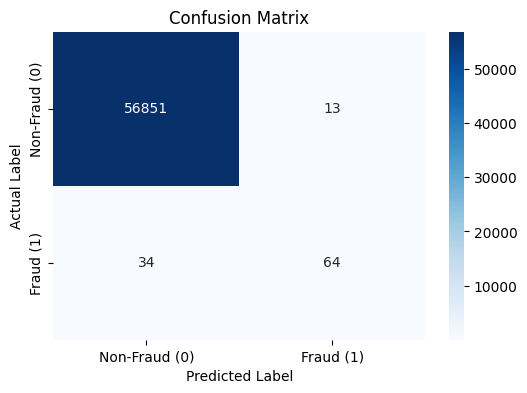

In [84]:
cm = confusion_matrix(y_test, y_pred_baseline)
labels = ["Non-Fraud (0)", "Fraud (1)"]

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

## change solver for better convergence instead of increasing iterations

In [78]:
# create the model
baselinelr = LogisticRegression(max_iter=1000, solver='liblinear')

In [79]:
baselinelr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

**`NOTE:`**
- So keeping iterations at 1000 works well but with liblinear solver

In [81]:
# make predictions
baselinepred= baselinelr.predict(X_test)

print("BASELINE MODEL")
print(classification_report(y_test, baselinepred))

BASELINE MODEL
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.67      0.70        98

    accuracy                           1.00     56962
   macro avg       0.86      0.84      0.85     56962
weighted avg       1.00      1.00      1.00     56962



# DISPLAY CONFUSION MATRIX TO COUNT; TP,TN, FP AND FN

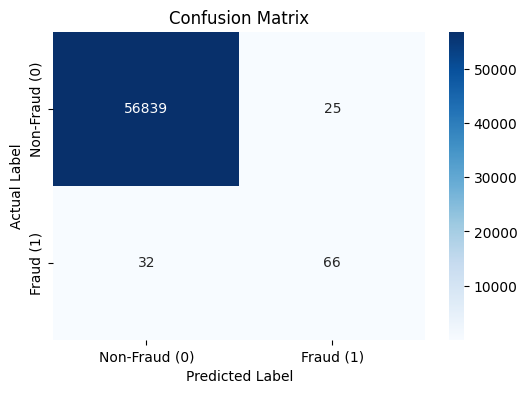

In [85]:
cm = confusion_matrix(y_test, baselinepred)
labels = ["Non-Fraud (0)", "Fraud (1)"]

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()